In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style
plt.style.use('fivethirtyeight')
sns.set_palette("deep")

# Load datasets
df = pd.read_csv('Highest Holywood Grossing Movies.csv')

# Rename columns to match the structure of the original dataset
df = df.rename(columns={
    'Title': 'movie',
    'Year': 'year',
    'Budget (in $)': 'production_budget',
    'Domestic Sales (in $)': 'domestic_gross',
    'International Sales (in $)': 'foreign_gross',
    'World Wide Sales (in $)': 'worldwide_gross',
    'Release Date': 'release_date',
    'Genre': 'genre_list',
    'Distributor': 'studio'
})

# Calculate derived columns that were in the original dataset
df['profit'] = df['worldwide_gross'] - df['production_budget']
df['profit_margin'] = df['profit'] / df['worldwide_gross']
df['roi'] = df['profit'] / df['production_budget']
df['pct_foreign'] = df['foreign_gross'] / df['worldwide_gross']

# Extract month from release date
df['month'] = pd.to_datetime(df['release_date'], errors='coerce').dt.month

# Convert genre_list from string to actual list if needed
df['genre_list'] = df['genre_list'].apply(lambda x: eval(x) if isinstance(x, str) else x)


In [2]:
yearly_data = df.groupby('year').agg({
    'domestic_gross': 'sum',
    'foreign_gross': 'sum',
    'worldwide_gross': 'sum'
}).reset_index()

# Create stacked area chart with Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=yearly_data['year'], 
    y=yearly_data['domestic_gross'],
    mode='lines',
    name='Domestic Gross',
    line=dict(width=0.5, color='rgb(131, 90, 241)'),
    stackgroup='one'
))
fig.add_trace(go.Scatter(
    x=yearly_data['year'], 
    y=yearly_data['foreign_gross'],
    mode='lines',
    name='Foreign Gross',
    line=dict(width=0.5, color='rgb(54, 162, 235)'),
    stackgroup='one'
))
fig.update_layout(
    title='Domestic vs Foreign Box Office Revenue Over Time',
    xaxis_title='Year',
    yaxis_title='Revenue (USD)',
    legend_title='Revenue Source',
    template='plotly_white',
    hovermode='x unified'
)
fig.show()


In [3]:
# Monthly analysis - Which months perform best?
monthly_data = df.groupby('month').agg({
    'worldwide_gross': 'mean',
    'profit_margin': 'mean',
    'movie': 'count'
}).reset_index()
monthly_data.columns = ['Month', 'Avg Worldwide Gross', 'Avg Profit Margin', 'Number of Movies']

# Create subplot with dual y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Bar(x=monthly_data['Month'], y=monthly_data['Avg Worldwide Gross'], 
           name="Avg Worldwide Gross", marker_color='rgb(26, 118, 255)'),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=monthly_data['Month'], y=monthly_data['Number of Movies'], 
               name="Number of Movies", marker_color='rgb(55, 83, 109)', mode='lines+markers'),
    secondary_y=True,
)
fig.update_layout(
    title='Monthly Release Performance',
    xaxis=dict(title='Month', tickmode='array', tickvals=list(range(1,13))),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0.8)'),
    template='plotly_white'
)
fig.update_yaxes(title_text="Average Worldwide Gross (USD)", secondary_y=False)
fig.update_yaxes(title_text="Number of Movies Released", secondary_y=True)
fig.show()


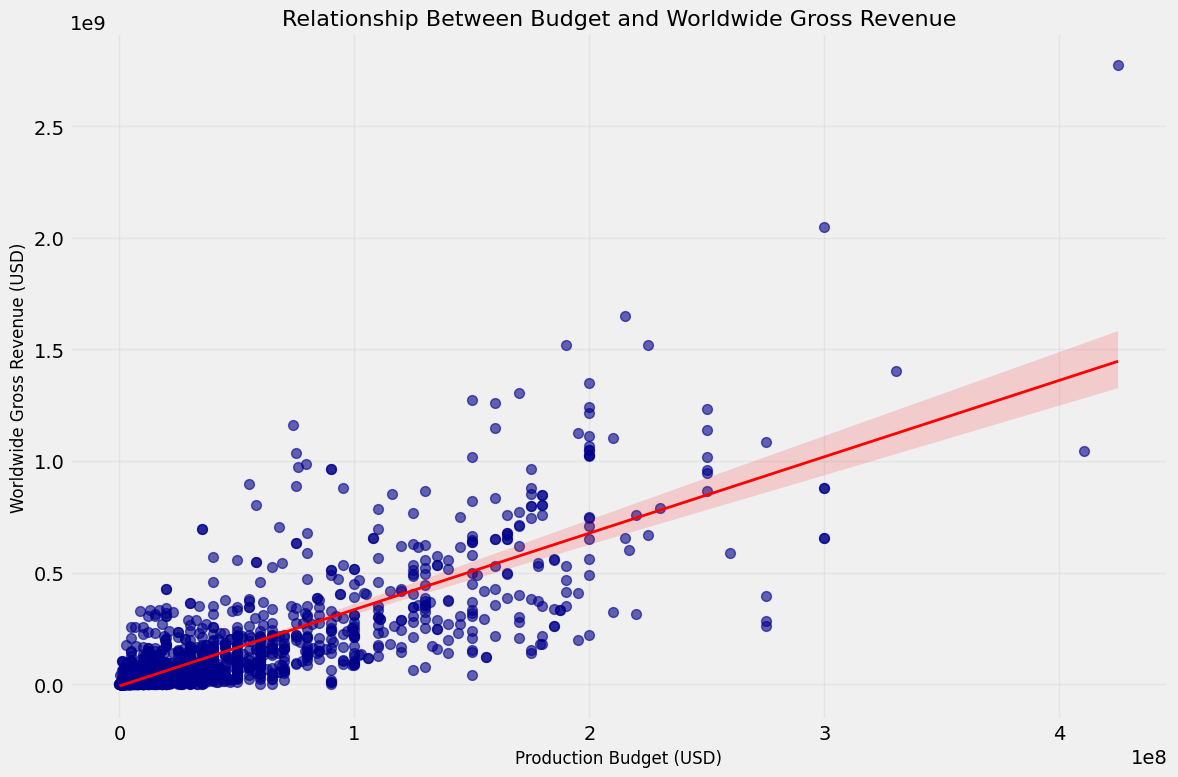

Correlation between budget and worldwide gross: 0.797


In [4]:
# Create scatter plot with regression line
plt.figure(figsize=(12, 8))
sns.regplot(x='production_budget', y='worldwide_gross', data=df, 
            scatter_kws={'alpha':0.6, 's':50, 'color':'darkblue'}, 
            line_kws={'color':'red', 'lw':2})
plt.title('Relationship Between Budget and Worldwide Gross Revenue', fontsize=16)
plt.xlabel('Production Budget (USD)', fontsize=12)
plt.ylabel('Worldwide Gross Revenue (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate and display correlation coefficient
correlation = df['production_budget'].corr(df['worldwide_gross'])
print(f"Correlation between budget and worldwide gross: {correlation:.3f}")

# Create an interactive bubble chart with Plotly
# Create a copy of the dataframe with absolute profit values for sizing
df_plot = df.copy()
df_plot['abs_profit'] = df_plot['profit'].abs()  # Use absolute values for sizing

fig = px.scatter(df_plot, x='production_budget', y='worldwide_gross', 
                 size='abs_profit', color='profit_margin',
                 hover_name='movie', log_x=True, log_y=True,
                 size_max=60, color_continuous_scale='Viridis',
                 title='Budget vs. Revenue (bubble size = |profit|, color = profit margin)')
fig.update_layout(template='plotly_white')
fig.show()


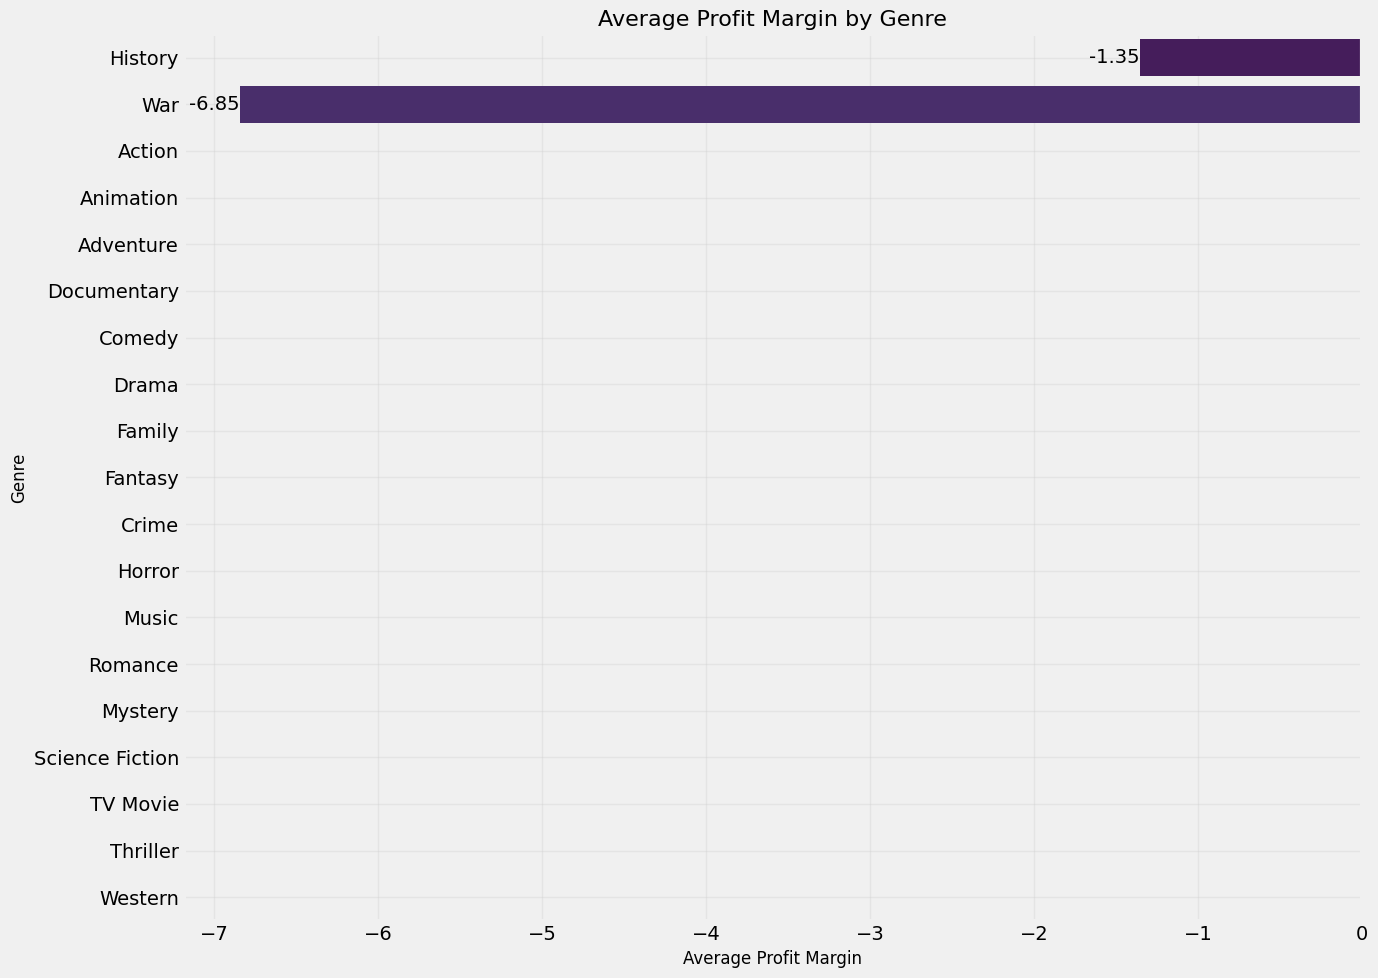

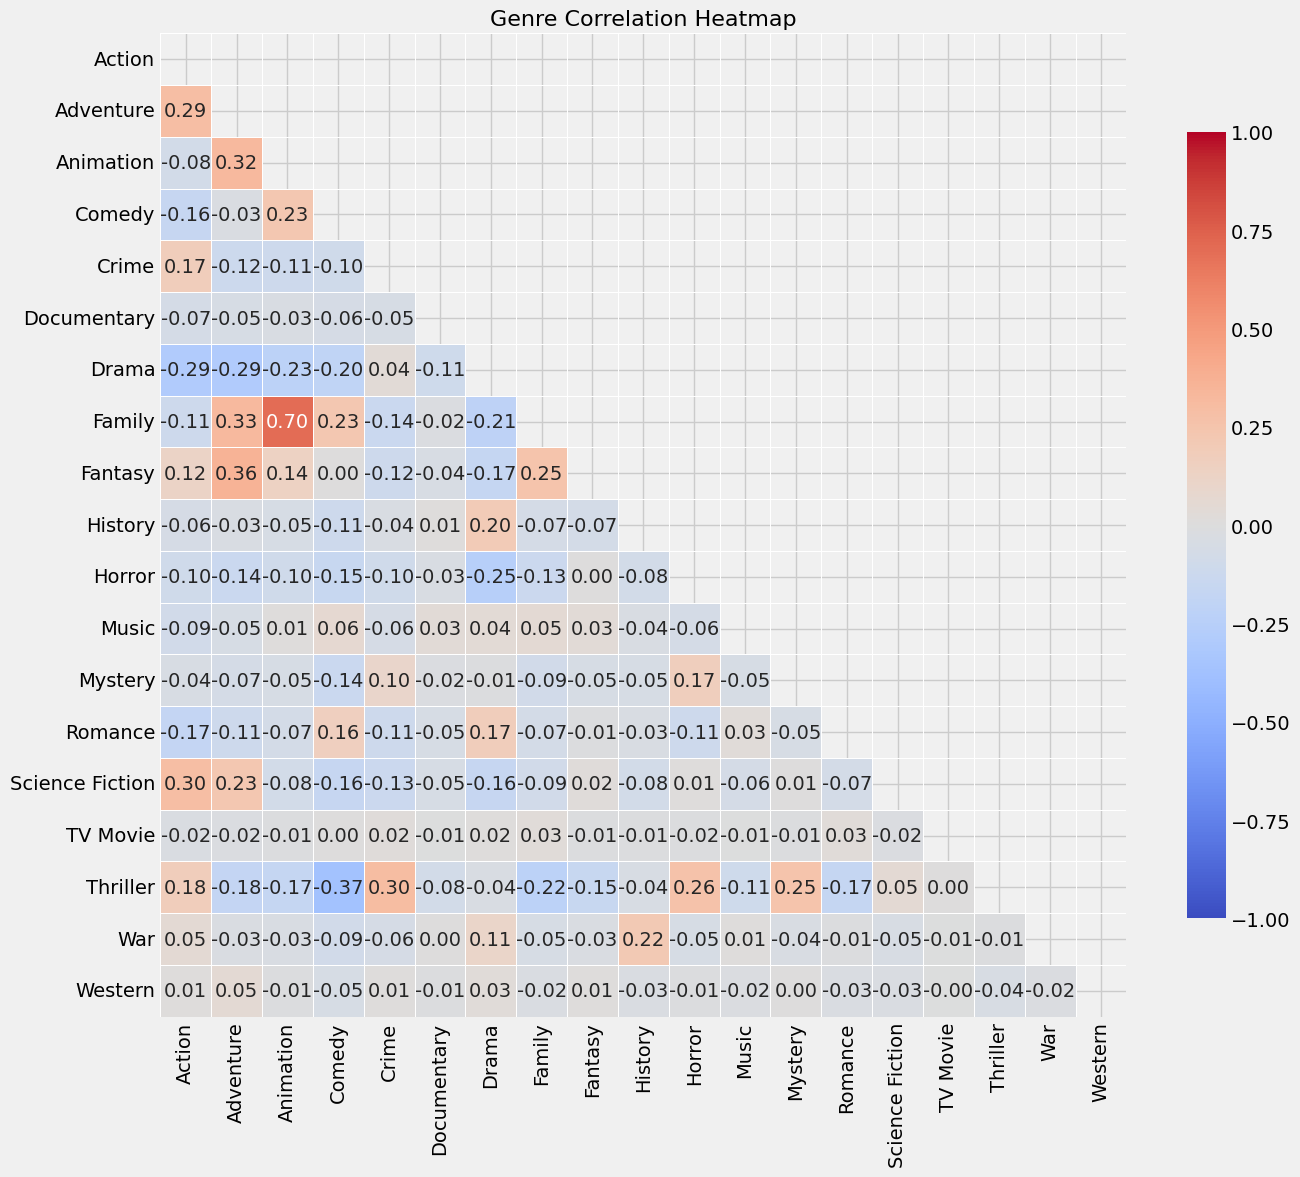

In [5]:
# Create a function to calculate genre-specific metrics
def analyze_genres(dataframe):
    genre_columns = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 
                     'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 
                     'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
    
    genre_metrics = []
    for genre in genre_columns:
        genre_movies = dataframe[dataframe[genre] == 1]
        if len(genre_movies) > 0:
            metrics = {
                'Genre': genre,
                'Count': len(genre_movies),
                'Avg Budget': genre_movies['production_budget'].mean(),
                'Avg Worldwide Gross': genre_movies['worldwide_gross'].mean(),
                'Avg Profit Margin': genre_movies['profit_margin'].mean(),
                'Avg ROI': genre_movies['roi'].mean()
            }
            genre_metrics.append(metrics)
    
    return pd.DataFrame(genre_metrics)

genre_df = analyze_genres(df)

# Create a horizontal bar chart for genre profitability
plt.figure(figsize=(14, 10))
sorted_genres = genre_df.sort_values('Avg Profit Margin', ascending=False)
ax = sns.barplot(x='Avg Profit Margin', y='Genre', data=sorted_genres, 
                palette='viridis')
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')
plt.title('Average Profit Margin by Genre', fontsize=16)
plt.xlabel('Average Profit Margin', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create a heatmap showing correlation between genres
# First, create a correlation matrix of genre columns
genre_columns = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 
                 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 
                 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
genre_corr = df[genre_columns].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(genre_corr, dtype=bool))
sns.heatmap(genre_corr, annot=True, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Genre Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()


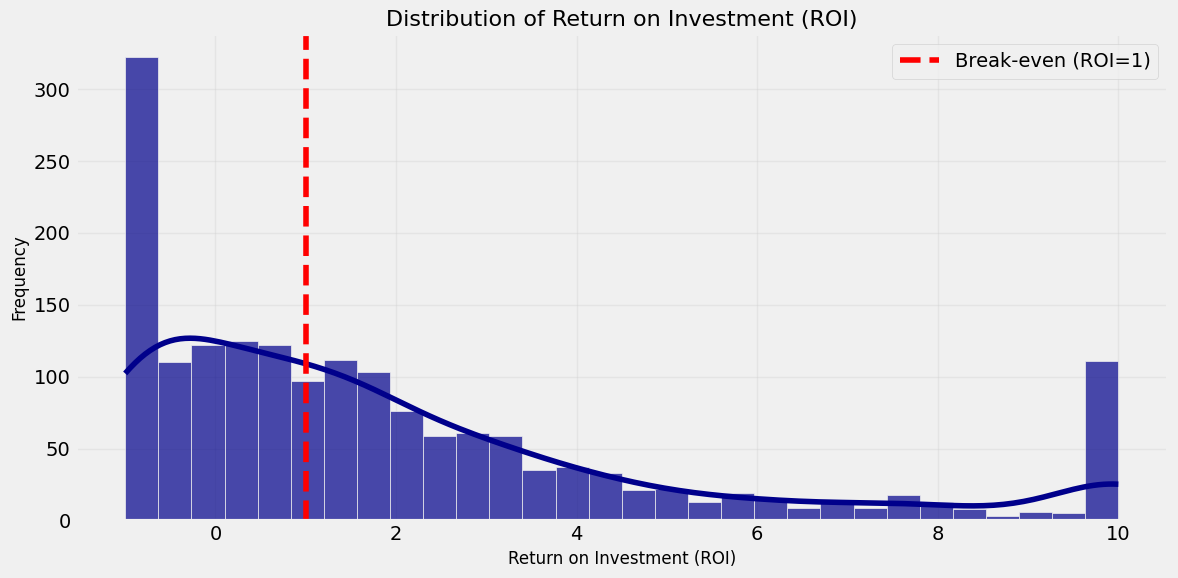

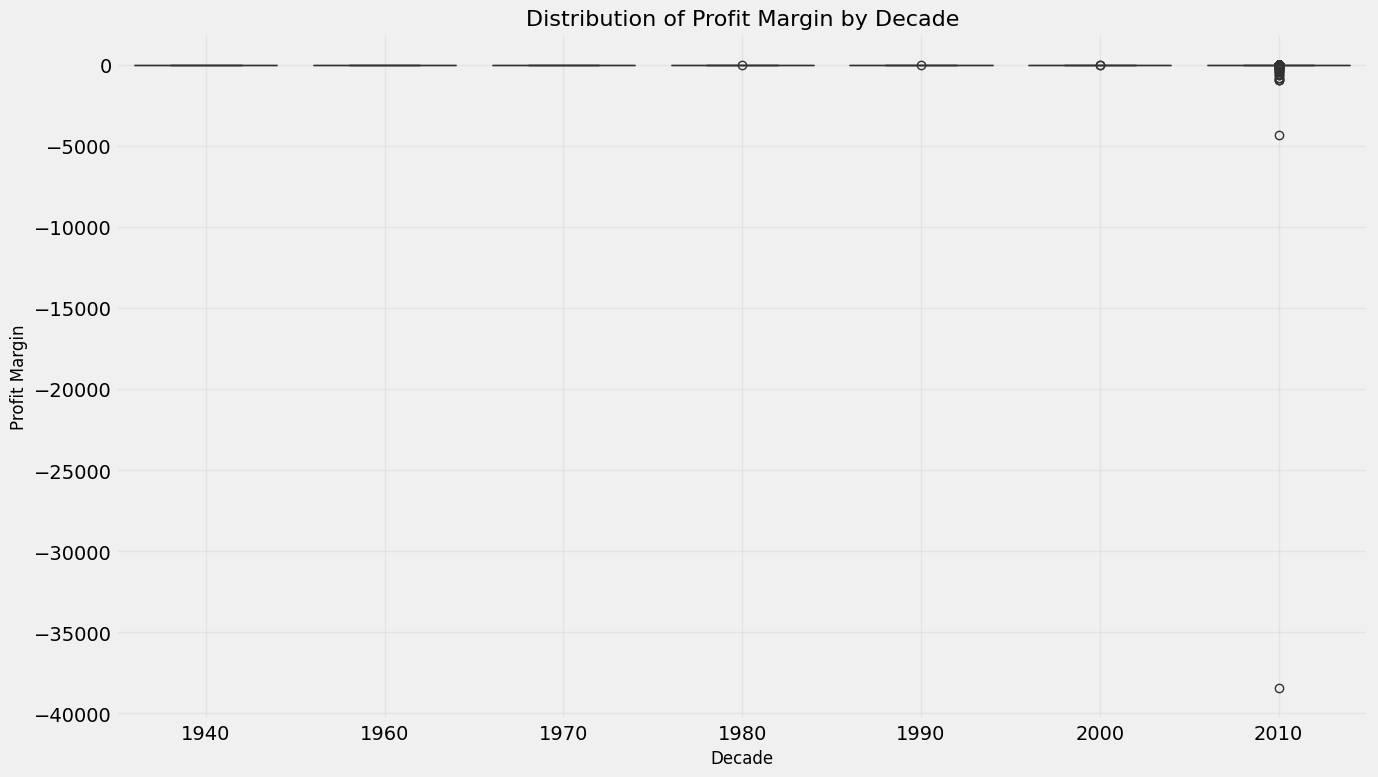

In [6]:
# Create histogram of ROI with KDE
plt.figure(figsize=(12, 6))
sns.histplot(df['roi'].clip(upper=10), kde=True, bins=30, color='darkblue', alpha=0.7)
plt.axvline(x=1, color='red', linestyle='--', label='Break-even (ROI=1)')
plt.title('Distribution of Return on Investment (ROI)', fontsize=16)
plt.xlabel('Return on Investment (ROI)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create boxplot for profit_margin by decade
df['decade'] = (df['year'] // 10) * 10
plt.figure(figsize=(14, 8))
sns.boxplot(x='decade', y='profit_margin', data=df, palette='viridis')
plt.title('Distribution of Profit Margin by Decade', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Profit Margin', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Top 10 most profitable movies (interactive table)
top_profitable = df.sort_values('profit', ascending=False).head(10)[
    ['movie', 'year', 'production_budget', 'worldwide_gross', 'profit', 'profit_margin', 'roi']
]

fig = go.Figure(data=[go.Table(
    header=dict(values=list(top_profitable.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[top_profitable[k].tolist() for k in top_profitable.columns],
               fill_color='lavender',
               align='left'))
])
fig.update_layout(title='Top 10 Most Profitable Movies')
fig.show()


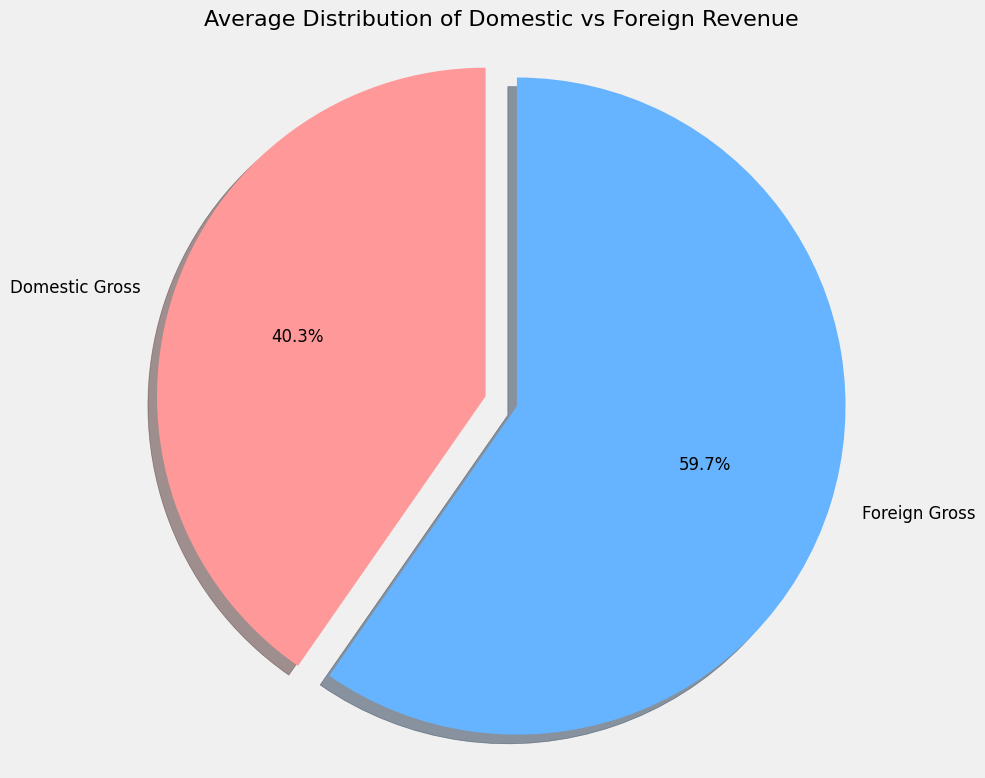

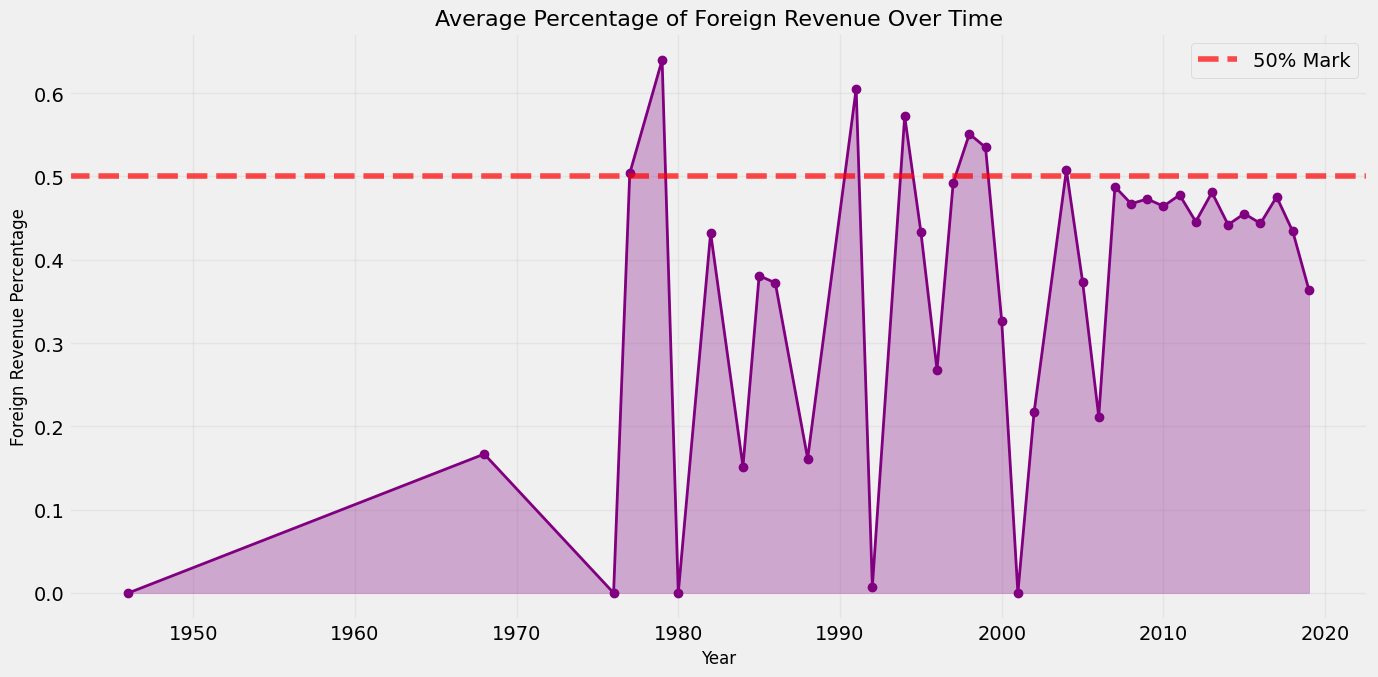

In [7]:
# Create a pie chart of average domestic vs foreign revenue share
avg_domestic = df['domestic_gross'].sum()
avg_foreign = df['foreign_gross'].sum()

labels = ['Domestic Gross', 'Foreign Gross']
sizes = [avg_domestic, avg_foreign]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)

plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
plt.axis('equal')
plt.title('Average Distribution of Domestic vs Foreign Revenue', fontsize=16)
plt.tight_layout()
plt.show()

# Foreign percentage over time
yearly_foreign_pct = df.groupby('year')['pct_foreign'].mean().reset_index()

plt.figure(figsize=(14, 7))
plt.plot(yearly_foreign_pct['year'], yearly_foreign_pct['pct_foreign'], 
         marker='o', linestyle='-', color='purple', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% Mark')
plt.fill_between(yearly_foreign_pct['year'], yearly_foreign_pct['pct_foreign'], 
                 alpha=0.3, color='purple')
plt.title('Average Percentage of Foreign Revenue Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Foreign Revenue Percentage', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


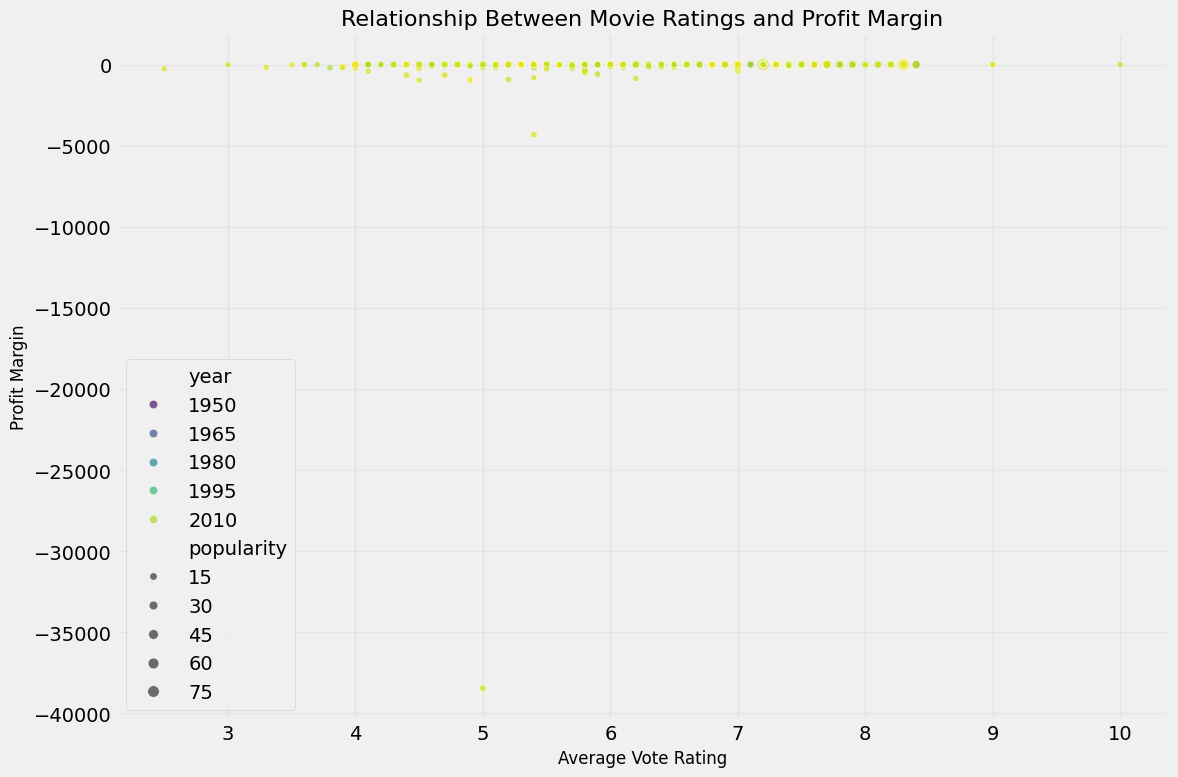

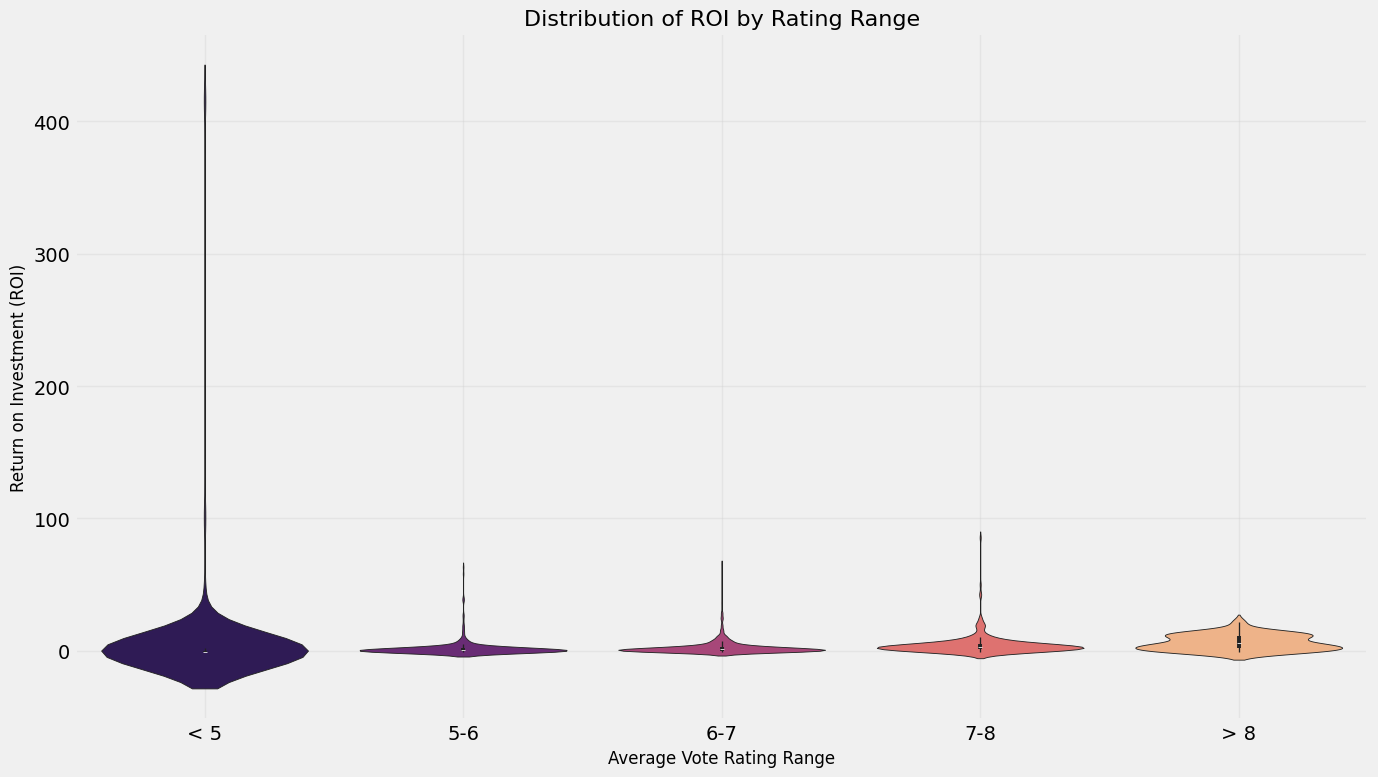

In [8]:
# Analyze relationship between ratings and financial performance
plt.figure(figsize=(12, 8))
sns.scatterplot(x='vote_average', y='profit_margin', 
                size='popularity', hue='year', 
                palette='viridis', data=df, alpha=0.7)
plt.title('Relationship Between Movie Ratings and Profit Margin', fontsize=16)
plt.xlabel('Average Vote Rating', fontsize=12)
plt.ylabel('Profit Margin', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create violin plots for profit by rating range
df['rating_range'] = pd.cut(df['vote_average'], 
                           bins=[0, 5, 6, 7, 8, 10], 
                           labels=['< 5', '5-6', '6-7', '7-8', '> 8'])

plt.figure(figsize=(14, 8))
sns.violinplot(x='rating_range', y='roi', data=df, palette='magma')
plt.title('Distribution of ROI by Rating Range', fontsize=16)
plt.xlabel('Average Vote Rating Range', fontsize=12)
plt.ylabel('Return on Investment (ROI)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
